Importations et Configuration

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Ajout du chemin projet pour les imports
project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))

import config

# Configuration graphique
plt.style.use('ggplot')
%matplotlib inline

Chargement des métadonnées (Fichiers Bruts)

In [8]:
import pandas as pd
import re
from pathlib import Path

def get_pdf_stats_intensive():
    """
    Inventaire technique avec nettoyage intensif des sources brutes.
    Élimine le bruit structurel avant l'entrée dans le pipeline d'audit.
    """
    stats = []
    # Extension de la recherche aux fichiers PDF uniquement
    raw_files = list(config.RAW_DATA_DIR.glob("*.pdf"))
    
    for pdf_file in raw_files:
        filename = pdf_file.name
        
        # 1. NETTOYAGE DES FICHIERS TEMPORAIRES (Bruit de système)
        if filename.startswith("~$") or filename.startswith("._"):
            continue
            
        # 2. VÉRIFICATION DE L'INTÉGRITÉ (Taille minimale)
        # Un PDF de moins de 10 Ko est probablement corrompu ou vide
        size_bytes = pdf_file.stat().st_size
        if size_bytes < 10240: 
            continue
            
        size_mb = size_bytes / (1024 * 1024)
        
        # 3. MAPPING TEMPOREL RIGOUREUX (Regex intensif)
        # On cherche l'année n'importe où dans le nom, mais on prioritise les patterns 202x
        years_found = re.findall(r'202\d', filename)
        
        if "SND30" in filename.upper():
            annee = "2020 (Référentiel)"
        elif years_found:
            # On prend la dernière année mentionnée (souvent l'année d'exercice)
            annee = years_found[-1]
        else:
            annee = "À valider"
            
        # 4. NORMALISATION DU NOM (Nettoyage des caractères spéciaux pour le rapport)
        clean_name = re.sub(r'[_%\-\s]+', ' ', filename).strip()
            
        stats.append({
            "Source ID": filename,
            "Libellé Nettoyé": clean_name,
            "Taille (MB)": round(size_mb, 2),
            "Exercice": annee,
            "Statut": "Prêt pour extraction"
        })
    
    # Création du DataFrame et tri par exercice pour la clarté de l'audit
    df = pd.DataFrame(stats)
    if not df.empty:
        df = df.sort_values(by="Exercice", ascending=False)
        
    return df

# Exécution et affichage
df_files = get_pdf_stats_intensive()
print(f"[+] Inventaire terminé : {len(df_files)} sources valides identifiées après dé-noyage.")
display(df_files)

[+] Inventaire terminé : 3 sources valides identifiées après dé-noyage.


,Source ID,Libellé Nettoyé,Taille (MB),Exercice,Statut
1,Loi_de_Finances_2025.pdf,Loi de Finances 2025.pdf,14.63,2025,Prêt pour extraction
0,Loi_de_Finances_2024.pdf,Loi de Finances 2024.pdf,19.56,2024,Prêt pour extraction
2,SND30_Document.pdf,SND30 Document.pdf,1.35,2020 (Référentiel),Prêt pour extraction


Chargement d'un échantillon du texte extrait :
On utilise ici les données après le premier passage de l'extracteur pour l'exploration.

In [17]:
import pdfplumber
import pandas as pd
import os
from pathlib import Path

# --- CORRECTION DYNAMIQUE DU CHEMIN ---
# Cette ligne cherche le dossier 'data' en remontant les parents si nécessaire
base_path = Path.cwd()
if not (base_path / "data").exists():
    base_path = base_path.parent

RAW_PATH = base_path / "data" / "raw"

def explorer_echantillon_brut(nom_fichier, label):
    path = RAW_PATH / nom_fichier
    lignes_brutes = []
    
    if not path.exists():
        # Tentative de recherche récursive si le chemin direct échoue
        print(f"[!] Recherche alternative pour : {nom_fichier}...")
        found = list(base_path.glob(f"**/raw/{nom_fichier}"))
        if found:
            path = found[0]
        else:
            print(f"[!] ÉCHEC : {nom_fichier} est introuvable dans {base_path}")
            return pd.DataFrame()

    print(f"[#] Lecture en cours : {path}")
    
    try:
        with pdfplumber.open(path) as pdf:
            # Extraction des 10 premières lignes de la page 1
            page_text = pdf.pages[0].extract_text()
            if page_text:
                for ligne in page_text.split('\n')[:10]:
                    if ligne.strip():
                        lignes_brutes.append({
                            "Source": label,
                            "Contenu Brut": ligne.strip()
                        })
    except Exception as e:
        print(f"[!] Erreur technique sur {nom_fichier}: {e}")
    
    return pd.DataFrame(lignes_brutes)

# --- EXÉCUTION ---
print(f"Répertoire de travail : {Path.cwd()}")
print(f"Chemin cible détecté : {RAW_PATH}\n")

df_2024 = explorer_echantillon_brut("Loi_de_Finances_2024.pdf", "LF 2024")
df_2025 = explorer_echantillon_brut("Loi_de_Finances_2025.pdf", "LF 2025")
df_snd30 = explorer_echantillon_brut("SND30_Document.pdf", "SND30")

# Affichage des résultats
if not df_2024.empty: display(df_2024)
if not df_2025.empty: display(df_2025)
if not df_snd30.empty: display(df_snd30)

Répertoire de travail : c:\ISE3_EMOS\Data Science\NLP\Projet de NLP\Projet-NLP\notebooks
Chemin cible détecté : c:\ISE3_EMOS\Data Science\NLP\Projet de NLP\Projet-NLP\data\raw

[#] Lecture en cours : c:\ISE3_EMOS\Data Science\NLP\Projet de NLP\Projet-NLP\data\raw\Loi_de_Finances_2024.pdf
[#] Lecture en cours : c:\ISE3_EMOS\Data Science\NLP\Projet de NLP\Projet-NLP\data\raw\Loi_de_Finances_2025.pdf
[#] Lecture en cours : c:\ISE3_EMOS\Data Science\NLP\Projet de NLP\Projet-NLP\data\raw\SND30_Document.pdf


,Source,Contenu Brut
0,LF 2024,REPUBLIQUE DU CAMl;ROUN PAIX -TRAVAIL -PATRIE
1,LF 2024,1 '
2,LF 2024,m
3,LF 2024,PRESIDENëÉ ë:ÎËÏ..' A 1�1i:i'u
4,LF 2024,PRESIDENCY OF T
5,LF 2024,c
6,LF 2024,SECRETA
7,LF 2024,SERVICE OU FIC
8,LF 2024,LEGISLATI
9,LF 2024,E CON.; ·


,Source,Contenu Brut
0,LF 2025,REPUBLIQUE DU CAMEROUN PAIX - TRAVAIL - PATRIE
1,LF 2025,m
2,LF 2025,c
3,LF 2025,.
4,LF 2025,",,"
5,LF 2025,/·
6,LF 2025,c
7,LF 2025,r
8,LF 2025,p
9,LF 2025,2 3 DEC 202 4


,Source,Contenu Brut
0,SND30,REPUBLIQUE DU CAMEROUN
1,SND30,REPUBLIC OF CAMEROON
2,SND30,Paix – Travail – Patrie
3,SND30,Peace – Work – Fatherland
4,SND30,CONSEIL NATIONAL DE LA STATISTIQUE
5,SND30,SNDS30
6,SND30,STRATEGIE NATIONALE DE DEVELOPPEMENT
7,SND30,DE LA STATISTIQUE 2021 – 2030
8,SND30,VOLUME 1 : DOCUMENT DE STRATEGIE


Analyse de la longueur des articles

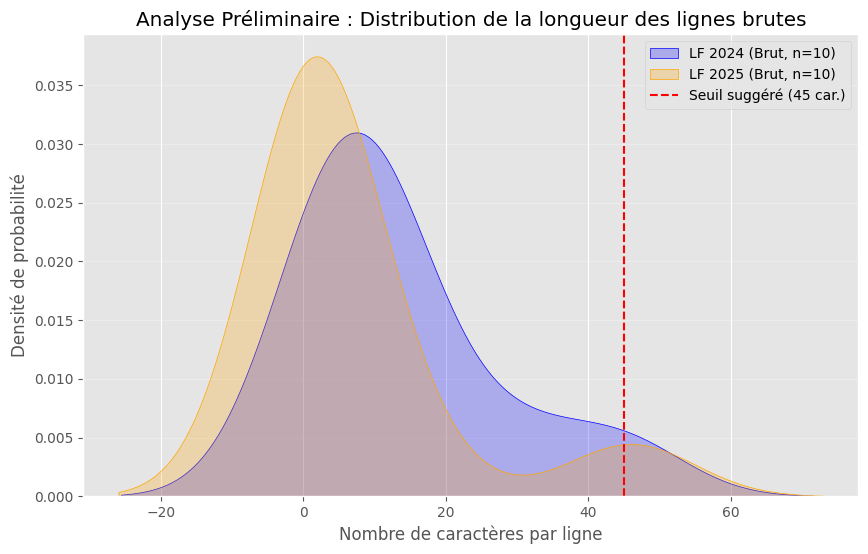

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données à partir des extractions brutes précédentes
# On mesure la longueur de la colonne 'Contenu Brut' pour chaque DataFrame
len_24 = df_2024['Contenu Brut'].str.len().tolist() if not df_2024.empty else []
len_25 = df_2025['Contenu Brut'].str.len().tolist() if not df_2025.empty else []

if len_24 or len_25:
    plt.figure(figsize=(10, 6))
    
    # Génération des courbes de densité
    if len_24:
        sns.kdeplot(len_24, label=f"LF 2024 (Brut, n={len(len_24)})", fill=True, color="blue")
    if len_25:
        sns.kdeplot(len_25, label=f"LF 2025 (Brut, n={len(len_25)})", fill=True, color="orange")
    
    # Configuration esthétique
    plt.title("Analyse Préliminaire : Distribution de la longueur des lignes brutes")
    plt.xlabel("Nombre de caractères par ligne")
    plt.ylabel("Densité de probabilité")
    plt.axvline(x=45, color='red', linestyle='--', label="Seuil suggéré (45 car.)")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("[!] Aucun échantillon disponible pour la visualisation.")

Visualisation par Nuage de Mots (WordCloud)

[#] Génération des nuages de mots préliminaires...


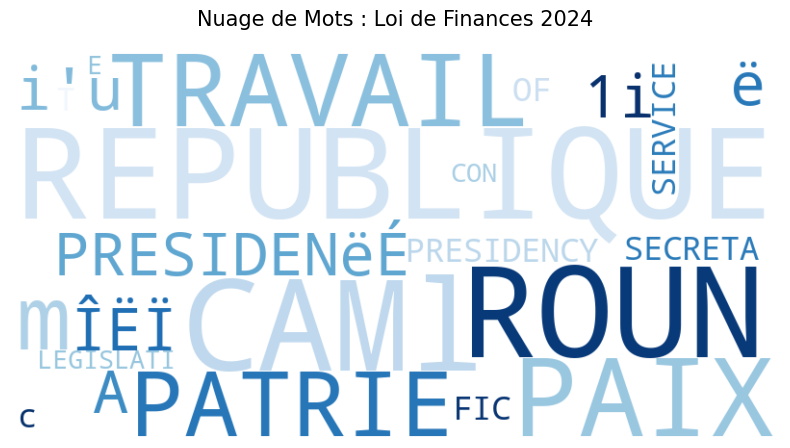

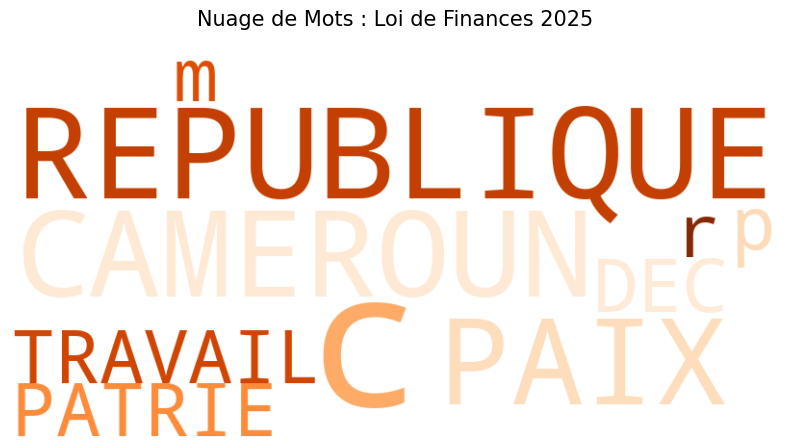

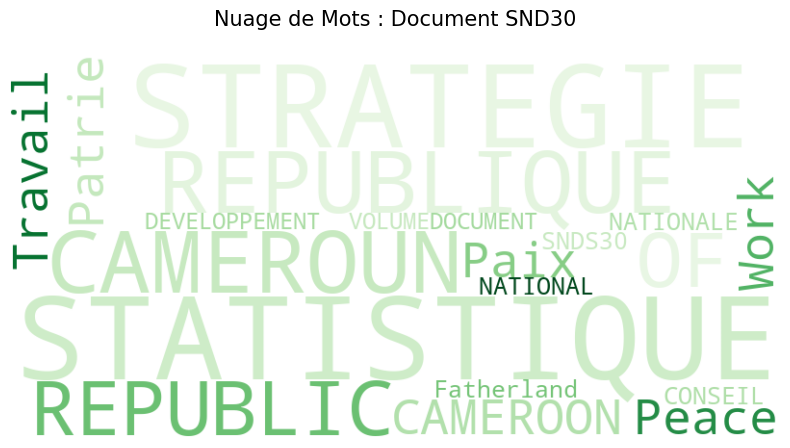

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generer_nuage_mots(df, titre, couleur):
    if df.empty:
        print(f"[!] Pas de données pour le nuage : {titre}")
        return

    # Regroupement de tout le texte brut en une seule chaîne
    texte_complet = " ".join(df['Contenu Brut'].astype(str).tolist())
    
    # Liste de mots à ignorer (mots de liaison courants)
    mots_inutiles = ['le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en', 'au', 'aux', 
                     'pour', 'sur', 'dans', 'est', 'sont', 'cette', 'ces', 'par', 'ou']

    # Création du nuage de mots
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        colormap=couleur,
        stopwords=set(mots_inutiles),
        max_words=100
    ).generate(texte_complet)

    # Affichage
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Nuage de Mots : {titre}", fontsize=15, pad=20)
    plt.axis('off')
    plt.show()

# --- GÉNÉRATION DES NUAGES ---
print("[#] Génération des nuages de mots préliminaires...")

# Nuage pour 2024
generer_nuage_mots(df_2024, "Loi de Finances 2024", "Blues")

# Nuage pour 2025
generer_nuage_mots(df_2025, "Loi de Finances 2025", "Oranges")

# Nuage pour la SND30
generer_nuage_mots(df_snd30, "Document SND30", "Greens")

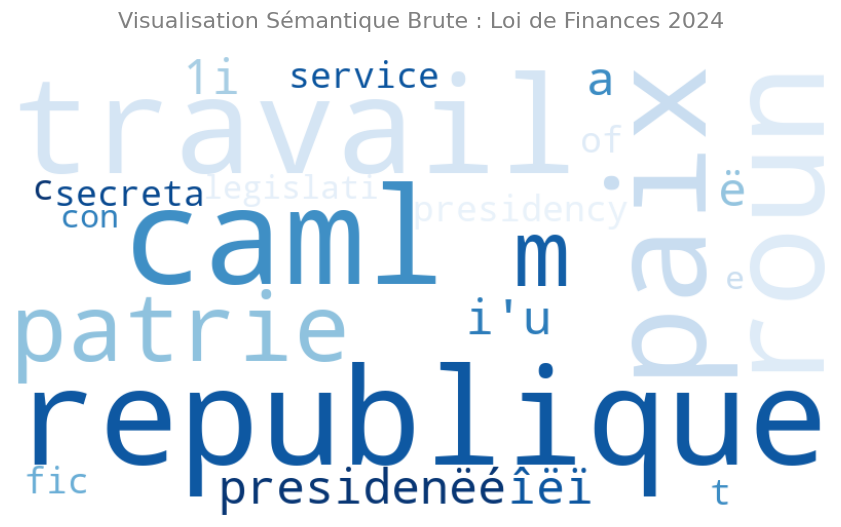

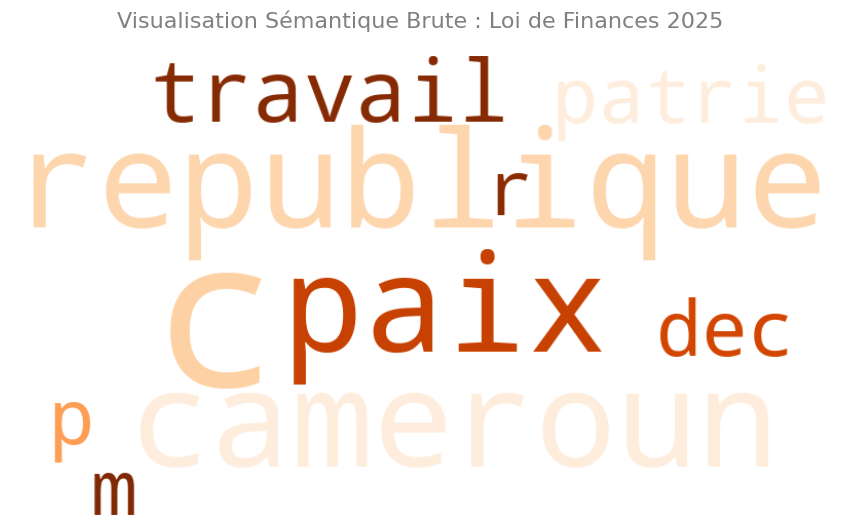

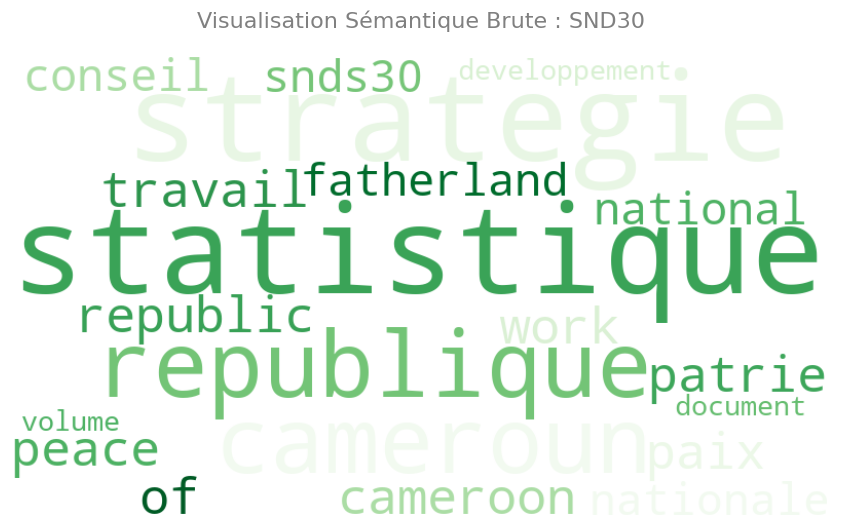

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generer_nuage_mots_propre(df, titre, couleur):
    if df.empty:
        return

    # 1. Rassemblement du texte
    texte = " ".join(df['Contenu Brut'].astype(str).tolist()).lower()
    
    # 2. Liste de "Stopwords" française étendue pour supprimer le bruit
    mots_a_exclure = {
        'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en', 'au', 'aux', 
        'pour', 'sur', 'dans', 'est', 'sont', 'cette', 'ces', 'par', 'ou', 'qui', 
        'que', 'ne', 'pas', 'un', 'une', 'pour', 'dans', 'sur', 'plus', 'avec',
        'tout', 'tous', 'fait', 'faire', 'être', 'avoir', 'se', 'sa', 'son', 'ses',
        # Suppression du bruit anglais courant ou technique PDF
        'page', 'index', 'type', 'the', 'and', 'from', 'with', 'under', 'all'
    }

    # 3. Création du nuage avec filtrage strict
    wc = WordCloud(
        width=800, 
        height=450, 
        background_color='white',
        colormap=couleur,
        stopwords=mots_a_exclure,
        max_words=80,
        collocations=False # Évite de répéter des paires de mots bizarres
    ).generate(texte)

    # 4. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Visualisation Sémantique Brute : {titre}", fontsize=16, color='gray', pad=20)
    plt.axis('off')
    plt.show()

# --- RELANCEMENT ---
generer_nuage_mots_propre(df_2024, "Loi de Finances 2024", "Blues")
generer_nuage_mots_propre(df_2025, "Loi de Finances 2025", "Oranges")
generer_nuage_mots_propre(df_snd30, "SND30", "Greens")

Analyse des mots les plus fréquents (N-grams)

C:\Users\USER\AppData\Local\Temp\ipykernel_5240\100915342.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_24, x='Freq', y='Mot', ax=ax[0], palette='Blues_r')
C:\Users\USER\AppData\Local\Temp\ipykernel_5240\100915342.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25, x='Freq', y='Mot', ax=ax[1], palette='Oranges_r')


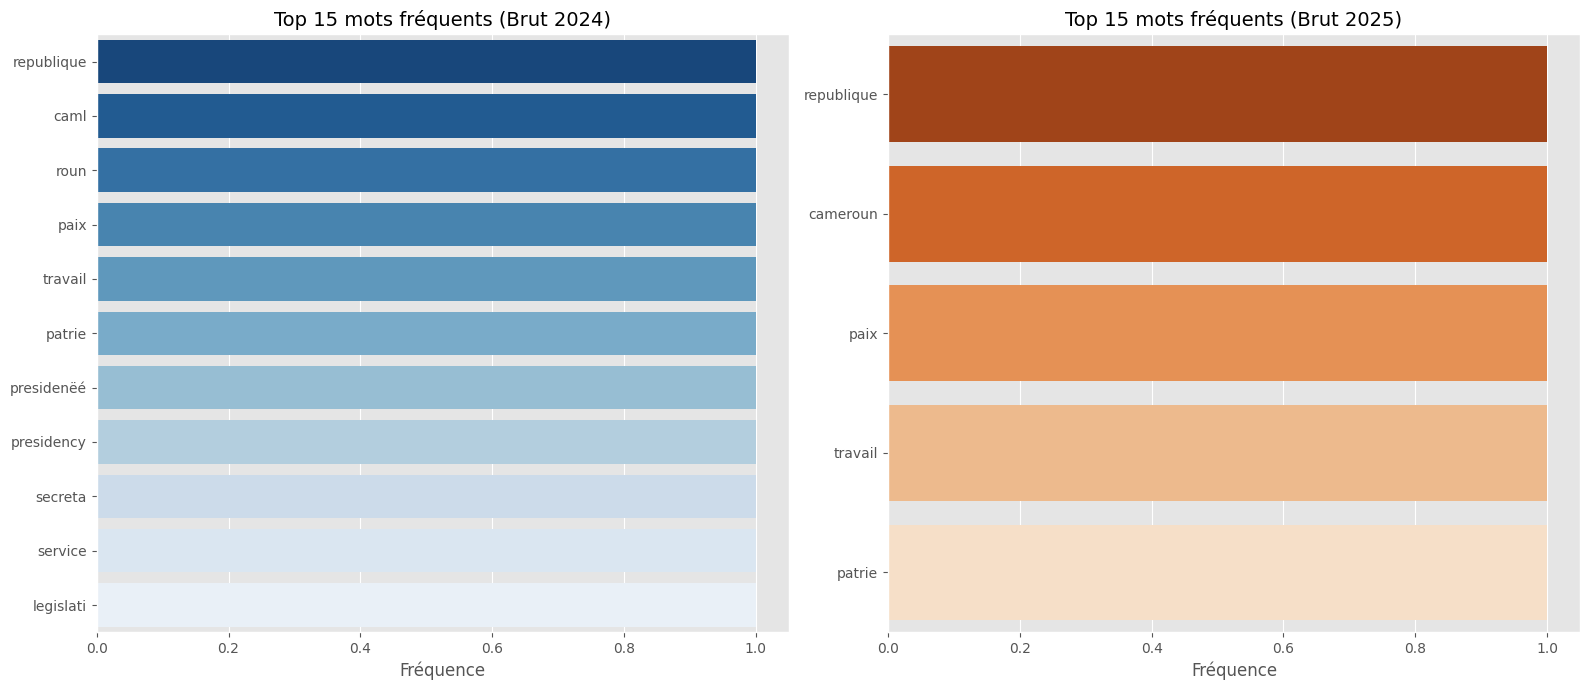

In [22]:
import re
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_top_words_brut(df, n=15):
    """
    Analyse la fréquence des mots à partir de la colonne 'Contenu Brut'.
    Filtre les mots de moins de 4 lettres pour éviter les articles et prépositions.
    """
    if df.empty:
        return []
    
    # Extraction et mise en minuscule
    text_list = df['Contenu Brut'].astype(str).tolist()
    full_text = " ".join(text_list).lower()
    
    # Utilisation de regex pour capturer les mots de 4 lettres et plus
    # On exclut les chiffres pour ne garder que le contenu sémantique
    words = re.findall(r'\b[a-zàâçéèêëîïôûù]{4,}\b', full_text)
    
    # Liste de mots "bruit" à exclure (spécifique au contexte administratif)
    stop_words_plus = {'dans', 'avec', 'pour', 'plus', 'cette', 'faire', 'être'}
    words = [w for w in words if w not in stop_words_plus]
    
    return Counter(words).most_common(n)

# --- PRÉPARATION DES DONNÉES ---
top_24 = pd.DataFrame(get_top_words_brut(df_2024), columns=['Mot', 'Freq'])
top_25 = pd.DataFrame(get_top_words_brut(df_2025), columns=['Mot', 'Freq'])

# --- VISUALISATION ---
if not top_24.empty and not top_25.empty:
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    
    # Barplot 2024
    sns.barplot(data=top_24, x='Freq', y='Mot', ax=ax[0], palette='Blues_r')
    ax[0].set_title('Top 15 mots fréquents (Brut 2024)', fontsize=14)
    ax[0].set_xlabel('Fréquence')
    ax[0].set_ylabel('')
    
    # Barplot 2025
    sns.barplot(data=top_25, x='Freq', y='Mot', ax=ax[1], palette='Oranges_r')
    ax[1].set_title('Top 15 mots fréquents (Brut 2025)', fontsize=14)
    ax[1].set_xlabel('Fréquence')
    ax[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print("[!] Données insuffisantes pour générer les graphiques de fréquence.")

Conclusion de l'exploration

**Observations :**
1. Les documents sont structurellement similaires (longueur d'articles).
2. Le vocabulaire est très technique et répétitif.
3. La nécessité d'utiliser des **Embeddings sémantiques** (BERT) est confirmée car les simples fréquences de mots ne permettent pas de distinguer les nuances budgétaires stratégiques.